In [1]:
import pyvista as pv
import numpy as np
import subprocess
import time

In [10]:
start_time = time.perf_counter()
result = subprocess.run(['/workspaces/nm/build/pde/e_emf_non'], cwd='.',
                        capture_output=True,
                        text=True,
                        check=True,
                        env={
                            "OMP_NUM_THREADS": "4"
                        })
end_time = time.perf_counter()

print(result.stdout)
print(result.stderr)
print(f"Execution time: {end_time - start_time:.4f} seconds")

[umsh][tel] zone: 18
[umsh][tel] vtx: 11850
[umsh][tel] qud: 11622
[umsh][tel] seg: 454
[fem][sys][asm] ok
[iss][gmr] itr: 2999
[iss][gmr] err: 1.9616668e+02
[fem][sys][slv] ok
Az(2.52e-02, 1.60e-03) = 9.7691398e+01
Bx(2.52e-02, 1.60e-03) = 1.8864538e+03
By(2.52e-02, 1.60e-03) = 9.2548962e+03
|B|(2.52e-02, 1.60e-03) = 9.4452005e+03
Az(3.35e-02, 2.70e-03) = 1.6280431e+01
Bx(3.35e-02, 2.70e-03) = -4.1775711e+03
By(3.35e-02, 2.70e-03) = 1.0058562e+04
|B|(3.35e-02, 2.70e-03) = 1.0891592e+04
Az(3.50e-02, 9.00e-04) = 1.0684850e+01
Bx(3.50e-02, 9.00e-04) = -5.2734792e+03
By(3.50e-02, 9.00e-04) = 8.7434724e+03
|B|(3.50e-02, 9.00e-04) = 1.0210675e+04
Az(3.65e-02, 2.70e-03) = -1.3895255e+01
Bx(3.65e-02, 2.70e-03) = -6.3693873e+03
By(3.65e-02, 2.70e-03) = 1.0058562e+04
|B|(3.65e-02, 2.70e-03) = 1.1905619e+04
Az(4.29e-02, 3.50e-03) = -8.7106263e+01
Bx(4.29e-02, 3.50e-03) = -1.1045262e+04
By(4.29e-02, 3.50e-03) = 1.0643046e+04
|B|(4.29e-02, 3.50e-03) = 1.5338587e+04


Execution time: 37.4608 second

2026-03-14 15:26:26.767 (   2.586s) [    7F0B6272E740]vtkXOpenGLRenderWindow.:1458  WARN| bad X server connection. DISPLAY=


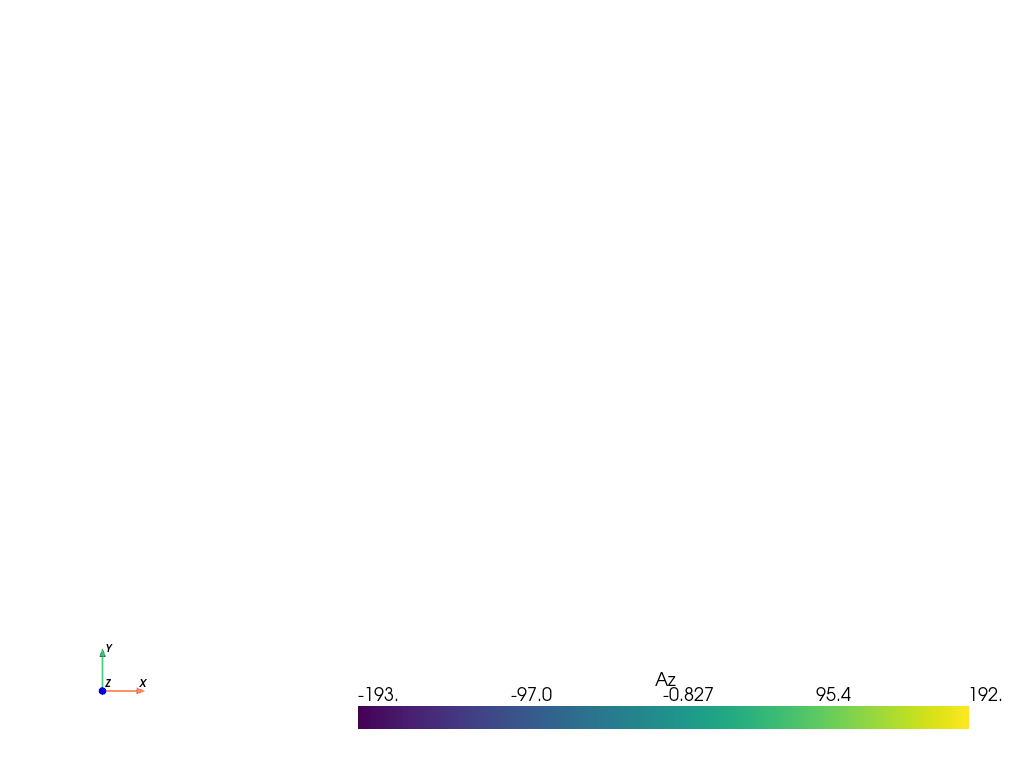

In [2]:
grid_az = pv.CGNSReader('out/emf-0.cgns').read().combine()
grid_bx = pv.CGNSReader('out/emf-1.cgns').read().combine()
grid_by = pv.CGNSReader('out/emf-2.cgns').read().combine()
grid_bm = pv.CGNSReader('out/emf-3.cgns').read().combine()

bx = grid_bx['Bx']
by = grid_by['By']
bm = grid_bm['Bm']

isolines = grid_az.contour(isosurfaces=20, scalars='Az')

ids = np.arange(0, grid_az.n_points, 3)
arrow_src = pv.PolyData(grid_az.points[ids])
arrow_src['B'] = np.c_[bx, by, np.zeros_like(bx)][ids]
arrow_src['Bm'] = bm[ids]

arrows = arrow_src.glyph(
    orient='B',
    scale='Bm',
    factor=0.002
)

plotter = pv.Plotter()

plotter.add_mesh(
    grid_az,
    scalars='Az',
    show_edges=True,
    cmap='viridis'
)

plotter.add_mesh(
    isolines,
    scalars='Az',
    line_width=2,
    cmap='viridis',
    show_scalar_bar=True
)

plotter.add_mesh(
    arrows,
    color='white',
    lighting=False
)

plotter.add_mesh(
    pv.Rectangle([[0.07, 0, 0], [0.07, 0.05, 0], [0, 0.05, 0]]),
    line_width=3,
    color='black',
    style='wireframe'
)

plotter.add_mesh(
    pv.Rectangle([[0.0225, 0.0225, 0], [0.0225, 0.0275, 0], [0.0175, 0.0275, 0]]),
    line_width=3,
    color='black',
    style='wireframe'
)

plotter.add_mesh(
    pv.Rectangle([[0.0525, 0.0225, 0], [0.0525, 0.0275, 0], [0.0475, 0.0275, 0]]),
    line_width=3,
    color='black',
    style='wireframe'
)

plotter.camera_position = 'xy'
plotter.reset_camera(bounds=[-1, 1.07, 0.0, 1.05, 0, 0])
plotter.zoom_camera(1)
plotter.show_axes()
plotter.show(jupyter_backend='static')